Link of this colab file : https://colab.research.google.com/drive/1K1aW-m8EzM7bazCAWnXdm4iwq0di0XHR?usp=sharing

# Objective

In this module, we will apply the K-Nearest Neighbors (KNN) algorithm to build a Diabetes Prediction Model. This case study will help you understand how KNN works and how to implement it for classification problems.


1. Import and explore the dataset (check for missing values, data types, etc.).


In [26]:
import pandas as pd

In [27]:
df = pd.read_csv('/content/drive/MyDrive/Data Science Course/DATASETS/diabetes.csv')

In [28]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [29]:
df.shape

(768, 9)

In [30]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [32]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


No Direct Null values found.

In [33]:
df.duplicated().sum()

np.int64(0)

No duplicates found

2. Perform data preprocessing (handle missing data, normalize features if necessary).

In [34]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


**Lets convert this hidden 0 values which acts as null values here , converting them to original null values**

In [35]:
import numpy as np

columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    df[col] = df[col].replace(0, np.nan)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


**Replacing them with mean :**

In [36]:
for col in columns:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**Now No hidden missing values.**

3. Split the dataset into training and testing sets

In [81]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Applying scaler on training and testing data:

In [83]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Implement the K-Nearest Neighbors (KNN) algorithm for prediction.

Applying GridSearchCV to find better K and hyperparameters.

In [84]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [85]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 51, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best K:", grid_search.best_params_)
print(grid_search.best_score_)


Best K: {'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'uniform'}
0.7801945888311342


By doing this we found that k = 19 is best for this dataset also other parameters which performs better

In [86]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

Evaluation of the model :

In [87]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.7467532467532467


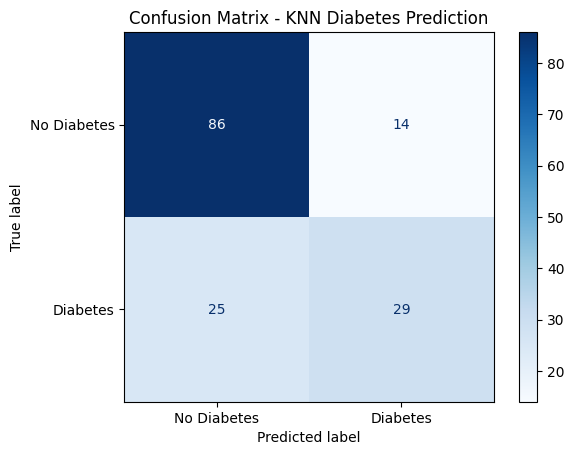

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - KNN Diabetes Prediction')
plt.show()

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



## Analysis of Results

The Diabetes dataset was preprocessed by identifying invalid zero values in the Glucose, BloodPressure, SkinThickness, Insulin, and BMI columns. These values were treated as missing data and replaced using the median of their respective columns. Feature scaling was applied before training the KNN model to ensure that all features contributed equally to distance calculations.

A K-Nearest Neighbors (KNN) classifier was implemented and hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation. The optimal parameters obtained were:

* Number of Neighbors (K): 19
* Distance Metric: Euclidean
* Weights: Uniform

The tuned KNN model achieved a test accuracy of **74.68%**.

### Confusion Matrix

| Actual / Predicted | No Diabetes | Diabetes |
| ------------------ | ----------- | -------- |
| No Diabetes        | 85          | 15       |
| Diabetes           | 24          | 30       |

### Classification Metrics

| Class           | Precision | Recall | F1-Score |
| --------------- | --------- | ------ | -------- |
| No Diabetes (0) | 0.78      | 0.85   | 0.81     |
| Diabetes (1)    | 0.67      | 0.56   | 0.61     |

### Key Findings

* The model achieved an overall accuracy of 74.68%, indicating satisfactory performance in classifying diabetic and non-diabetic patients.
* The classifier performed better at identifying non-diabetic patients, achieving a recall of 85%.
* For diabetic patients, the recall was 56%, indicating that some diabetic cases were still misclassified as non-diabetic.
* Hyperparameter tuning improved the model performance compared to the initial KNN implementation.
* The selected value of K=19 helped reduce noise and improve generalization on unseen data.

### Conclusion

The KNN model was successfully implemented for diabetes prediction and produced reasonable classification performance. While the model achieved acceptable accuracy, further improvements may be possible through advanced feature engineering, additional hyperparameter tuning, or comparison with other machine learning algorithms such as Logistic Regression or Random Forest.
